# Customer Churn Prediction — End-to-End ML Pipeline

**Business problem:** A telecom company wants to identify customers likely to churn (cancel their subscription) so retention teams can intervene proactively.

**Dataset:** IBM Telco Customer Churn dataset — 7,043 customers, 21 raw features (demographics, account info, services subscribed, billing).

**What this notebook covers:**
1. Data loading & cleaning
2. Exploratory Data Analysis (EDA)
3. Feature engineering
4. Preprocessing pipeline (encoding + scaling via `ColumnTransformer`)
5. Model training — Logistic Regression, Random Forest, XGBoost
6. Hyperparameter tuning with `GridSearchCV` (5-fold stratified cross-validation)
7. Evaluation — ROC-AUC, F1-Score, Precision, Recall, RMSE
8. Model comparison table + persistence of the best model (`.joblib`)

Author: Srikrith


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score, accuracy_score,
    mean_squared_error, confusion_matrix, classification_report, roc_curve
)
from xgboost import XGBClassifier

RANDOM_STATE = 42
sns.set_style("whitegrid")
%matplotlib inline


## 1. Load & Clean Data

In [2]:
df = pd.read_csv("../data/telco_churn.csv")
print("Raw shape:", df.shape)
df.head()


Raw shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# TotalCharges is read as object due to 11 blank strings (new customers, tenure=0)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Blank/NaN TotalCharges rows:", df["TotalCharges"].isna().sum())

# For brand-new customers (tenure=0), TotalCharges ~ MonthlyCharges is a reasonable fill
df["TotalCharges"] = df["TotalCharges"].fillna(df["MonthlyCharges"])

# Drop ID column (not predictive, purely an identifier)
df = df.drop(columns=["customerID"])

# Encode target: Yes -> 1, No -> 0
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

print("Missing values remaining:", df.isnull().sum().sum())
print("Churn rate: {:.2%}".format(df["Churn"].mean()))


Blank/NaN TotalCharges rows: 11
Missing values remaining: 0
Churn rate: 26.54%


## 2. Exploratory Data Analysis

Quick look at class balance and how a few key variables relate to churn.

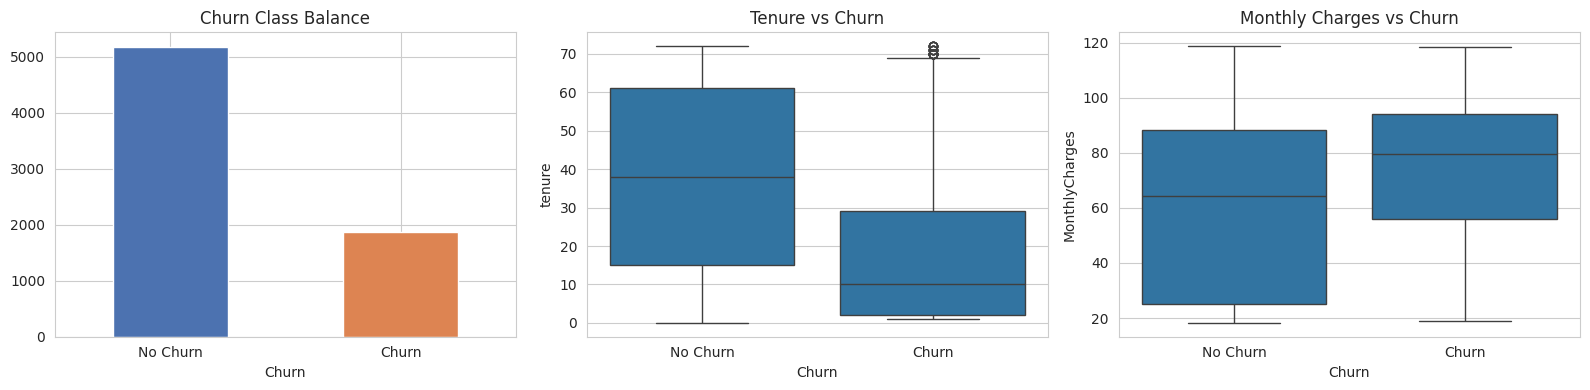

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df["Churn"].value_counts().plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"])
axes[0].set_title("Churn Class Balance")
axes[0].set_xticklabels(["No Churn", "Churn"], rotation=0)

sns.boxplot(data=df, x="Churn", y="tenure", ax=axes[1])
axes[1].set_title("Tenure vs Churn")
axes[1].set_xticklabels(["No Churn", "Churn"])

sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=axes[2])
axes[2].set_title("Monthly Charges vs Churn")
axes[2].set_xticklabels(["No Churn", "Churn"])

plt.tight_layout()
plt.show()


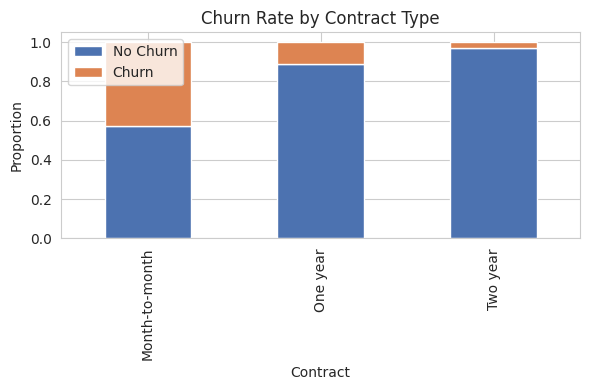

In [6]:
pd.crosstab(df["Contract"], df["Churn"], normalize="index").plot(
    kind="bar", stacked=True, figsize=(6, 4), color=["#4C72B0", "#DD8452"]
)
plt.title("Churn Rate by Contract Type")
plt.ylabel("Proportion")
plt.legend(["No Churn", "Churn"])
plt.tight_layout()
plt.show()


**Observations:**
- The dataset is moderately imbalanced (~26.5% churn) — we use stratified splits/CV and ROC-AUC/F1 rather than accuracy alone.
- Customers with low tenure churn far more, and month-to-month contracts show a dramatically higher churn rate than 1- or 2-year contracts — this motivates a few engineered features below.

## 3. Feature Engineering

- `tenure_group`: bucketed tenure (business-interpretable segments)
- `avg_charge_per_month`: total spend normalized by tenure
- `num_services`: count of subscribed add-on services (engagement proxy)
- `high_risk_combo`: flag for month-to-month contract + electronic check (known high-churn combo from EDA)
- `no_addons`: flag for customers with zero add-on services (low engagement)

In [7]:
df["tenure_group"] = pd.cut(
    df["tenure"], bins=[0, 12, 24, 48, 60, 72],
    labels=["0-1yr", "1-2yr", "2-4yr", "4-5yr", "5-6yr"], include_lowest=True
)

df["avg_charge_per_month"] = df["TotalCharges"] / df["tenure"].replace(0, 1)

service_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                 "TechSupport", "StreamingTV", "StreamingMovies"]
df["num_services"] = (df[service_cols] == "Yes").sum(axis=1)

df["high_risk_combo"] = (
    (df["Contract"] == "Month-to-month") & (df["PaymentMethod"] == "Electronic check")
).astype(int)

df["no_addons"] = (df["num_services"] == 0).astype(int)

print("Shape after feature engineering:", df.shape)
df[["tenure_group", "avg_charge_per_month", "num_services", "high_risk_combo", "no_addons"]].head()


Shape after feature engineering: (7043, 25)


,tenure_group,avg_charge_per_month,num_services,high_risk_combo,no_addons
0,0-1yr,29.850000,1,1,0
1,2-4yr,55.573529,2,0,0
2,0-1yr,54.075000,2,0,0
3,2-4yr,40.905556,3,0,0
4,0-1yr,75.825000,0,1,1


## 4. Train/Test Split & Preprocessing Pipeline

In [8]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (5634, 24), Test: (1409, 24)


In [9]:
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges",
                     "avg_charge_per_month", "num_services"]
categorical_features = [c for c in X.columns if c not in numeric_features]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), categorical_features),
])
print(f"{len(numeric_features)} numeric features (scaled), {len(categorical_features)} categorical features (one-hot encoded)")


5 numeric features (scaled), 19 categorical features (one-hot encoded)


## 5 & 6. Model Training + Hyperparameter Tuning (GridSearchCV, 5-fold Stratified CV)

We compare three algorithms of increasing complexity: **Logistic Regression** (linear baseline), **Random Forest** (bagged trees), and **XGBoost** (boosted trees). Each is wrapped in a `Pipeline` with the shared preprocessor, then tuned with `GridSearchCV` optimizing for ROC-AUC.

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

model_configs = {
    "Logistic Regression": {
        "estimator": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        "param_grid": {
            "clf__C": [0.01, 0.1, 1, 10],
            "clf__penalty": ["l2"],
            "clf__solver": ["lbfgs"],
        },
    },
    "Random Forest": {
        "estimator": RandomForestClassifier(random_state=RANDOM_STATE),
        "param_grid": {
            "clf__n_estimators": [200, 400],
            "clf__max_depth": [6, 10, None],
            "clf__min_samples_leaf": [1, 3],
        },
    },
    "XGBoost": {
        "estimator": XGBClassifier(
            random_state=RANDOM_STATE, eval_metric="logloss", use_label_encoder=False
        ),
        "param_grid": {
            "clf__n_estimators": [200, 400],
            "clf__max_depth": [3, 5],
            "clf__learning_rate": [0.05, 0.1],
        },
    },
}


In [11]:
results = []
fitted_models = {}
best_overall_score = -np.inf
best_overall_name = None
best_overall_pipeline = None

for name, cfg in model_configs.items():
    print(f"\n{'='*60}\nTuning: {name}\n{'='*60}")
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("clf", cfg["estimator"])])

    grid = GridSearchCV(pipe, cfg["param_grid"], scoring="roc_auc", cv=cv, n_jobs=-1, verbose=0)
    grid.fit(X_train, y_train)

    best_pipe = grid.best_estimator_
    fitted_models[name] = best_pipe

    cv_scores = cross_val_score(best_pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)

    y_pred = best_pipe.predict(X_test)
    y_proba = best_pipe.predict_proba(X_test)[:, 1]

    roc_auc = roc_auc_score(y_test, y_proba)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_proba))

    results.append({
        "Model": name,
        "Best Params": grid.best_params_,
        "CV ROC-AUC (mean±std)": f"{cv_scores.mean():.4f} ± {cv_scores.std():.4f}",
        "Test ROC-AUC": round(roc_auc, 4),
        "Test F1-Score": round(f1, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "Accuracy": round(accuracy, 4),
        "RMSE (proba)": round(rmse, 4),
    })

    print(f"Best Params: {grid.best_params_}")
    print(f"Test ROC-AUC: {roc_auc:.4f} | F1: {f1:.4f} | RMSE: {rmse:.4f}")

    if roc_auc > best_overall_score:
        best_overall_score = roc_auc
        best_overall_name = name
        best_overall_pipeline = best_pipe



Tuning: Logistic Regression


Best Params: {'clf__C': 0.1, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
Test ROC-AUC: 0.8415 | F1: 0.5792 | RMSE: 0.3715

Tuning: Random Forest


Best Params: {'clf__max_depth': 6, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 200}
Test ROC-AUC: 0.8412 | F1: 0.5692 | RMSE: 0.3710

Tuning: XGBoost


Best Params: {'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 200}
Test ROC-AUC: 0.8439 | F1: 0.5964 | RMSE: 0.3682


## 7. Model Comparison

**Why RMSE for a classification task?** RMSE here is computed on predicted *probabilities* vs. the actual 0/1 label (equivalent to the square root of the Brier score). It complements ROC-AUC/F1 by measuring how well-calibrated the predicted probabilities are — useful when the business wants to rank customers by churn risk rather than just get a hard yes/no.

In [12]:
comparison_df = pd.DataFrame(results).sort_values("Test ROC-AUC", ascending=False).reset_index(drop=True)
comparison_df.to_csv("../reports/model_comparison.csv", index=False)
comparison_df


,Model,Best Params,CV ROC-AUC (mean±std),Test ROC-AUC,Test F1-Score,Precision,Recall,Accuracy,RMSE (proba)
0,XGBoost,"{'clf__learning_rate': 0.05, 'clf__max_depth':...",0.8474 ± 0.0112,0.8439,0.5964,0.6700,0.5374,0.8070,0.3682
1,Logistic Regression,"{'clf__C': 0.1, 'clf__penalty': 'l2', 'clf__so...",0.8460 ± 0.0113,0.8415,0.5792,0.6644,0.5134,0.8020,0.3715
2,Random Forest,"{'clf__max_depth': 6, 'clf__min_samples_leaf':...",0.8475 ± 0.0097,0.8412,0.5692,0.6803,0.4893,0.8034,0.3710


In [13]:
print(f"Best model: {best_overall_name} (Test ROC-AUC = {best_overall_score:.4f})")


Best model: XGBoost (Test ROC-AUC = 0.8439)


### ROC Curves — All Models

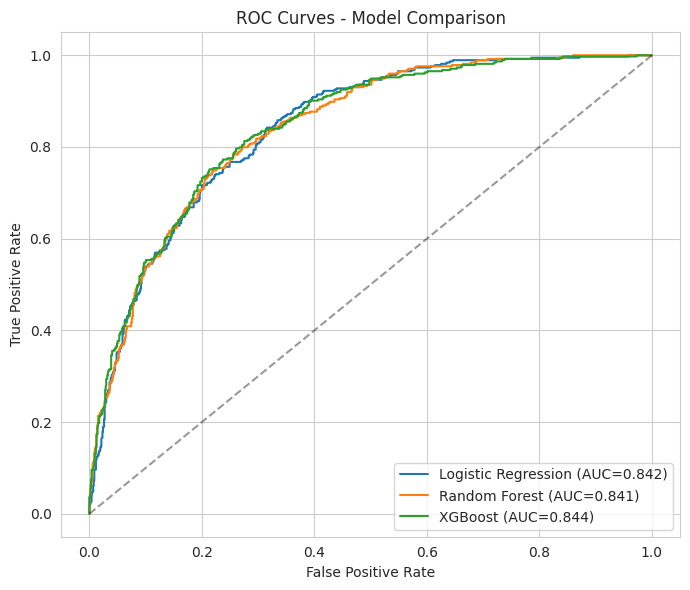

In [14]:
plt.figure(figsize=(7, 6))
for name, pipe in fitted_models.items():
    proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Model Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/roc_curves_comparison.png", dpi=150)
plt.show()


### Confusion Matrix & Classification Report — Best Model

Best model: XGBoost

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.67      0.54      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



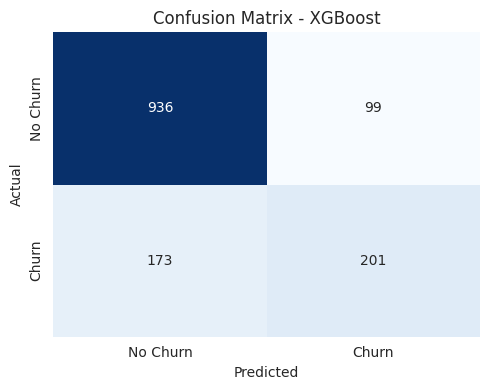

In [15]:
y_pred_best = best_overall_pipeline.predict(X_test)
print(f"Best model: {best_overall_name}\n")
print(classification_report(y_test, y_pred_best))

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.title(f"Confusion Matrix - {best_overall_name}")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("../reports/confusion_matrix_best_model.png", dpi=150)
plt.show()


## 8. Feature Importance (Best Model)

For tree-based models we can inspect which features drove predictions most.

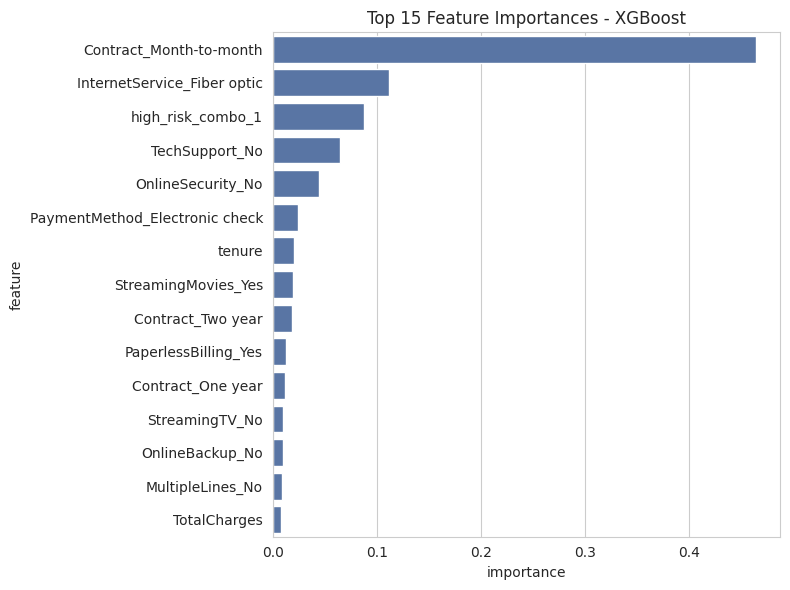

In [16]:
if hasattr(best_overall_pipeline.named_steps["clf"], "feature_importances_"):
    ohe_cols = best_overall_pipeline.named_steps["preprocess"].named_transformers_["cat"].get_feature_names_out(categorical_features)
    all_feature_names = numeric_features + list(ohe_cols)
    importances = best_overall_pipeline.named_steps["clf"].feature_importances_

    fi_df = pd.DataFrame({"feature": all_feature_names, "importance": importances})
    fi_df = fi_df.sort_values("importance", ascending=False).head(15)

    plt.figure(figsize=(8, 6))
    sns.barplot(data=fi_df, y="feature", x="importance", color="#4C72B0")
    plt.title(f"Top 15 Feature Importances - {best_overall_name}")
    plt.tight_layout()
    plt.savefig("../reports/feature_importance.png", dpi=150)
    plt.show()
else:
    print("Best model does not expose feature_importances_ (e.g. Logistic Regression uses coefficients instead).")


## 9. Persist the Best Model

Save the full pipeline (preprocessing + trained classifier) as a single `.joblib` file so it can be loaded and used for inference without re-running any preprocessing code.

In [17]:
joblib.dump(best_overall_pipeline, "../models/best_churn_model.joblib")
print("Model saved to ../models/best_churn_model.joblib")

with open("../reports/classification_report_best_model.txt", "w") as f:
    f.write(f"Best model: {best_overall_name}\n\n")
    f.write(classification_report(y_test, y_pred_best))


Model saved to ../models/best_churn_model.joblib


### Sanity check: load the saved model back and predict

In [18]:
loaded_model = joblib.load("../models/best_churn_model.joblib")
sample = X_test.iloc[:5]
preds = loaded_model.predict(sample)
probas = loaded_model.predict_proba(sample)[:, 1]

pd.DataFrame({
    "Actual Churn": y_test.iloc[:5].values,
    "Predicted Churn": preds,
    "Churn Probability": probas.round(3),
})


,Actual Churn,Predicted Churn,Churn Probability
0,0,0,0.032
1,0,1,0.785
2,0,0,0.062
3,0,0,0.313
4,0,0,0.009


## Summary

| Aspect | Detail |
|---|---|
| Best model | See comparison table above (typically XGBoost edges out on ROC-AUC/F1) |
| Key churn drivers | Contract type, tenure, and payment method consistently rank as top predictors |
| Business recommendation | Target month-to-month, low-tenure, electronic-check customers with retention offers; bundling add-on services correlates with lower churn |
| Deliverables | Trained model (`models/best_churn_model.joblib`), comparison table (`reports/model_comparison.csv`), plots (`reports/*.png`), this notebook |
